In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [ ]:
def wrangle (file_path):
  """
  Reads a CSV file and returns a clean DataFrame.

  Parameters:
  file_path (str): The path to the CSV file.

  Returns:
  df (pandas.DataFrame): A clean DataFrame
  """
  df = pd.read_csv(file_path)

  # Converting 'tenure' to an int and cleaning the columns
  df['tenure'] = df['tenure'].astype(float)

  # Converting to Float
  df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
  df[['TotalCharges', 'MonthlyCharges']] = df[['TotalCharges', 'MonthlyCharges']].astype(float)

  # Filling Missing Values with Specific Mean
  df.groupby('tenure')['TotalCharges'].mean().head()
  df[['TotalCharges','MonthlyCharges']] = df[['TotalCharges','MonthlyCharges']].fillna(
      df.groupby('tenure')['TotalCharges'].mean())

  # Converting Tenure from Month to Year
  df['tenure'] = round (df['tenure'] / 12, 2)

  # Segregating Customers by tenure
  def replace_values (column):
    if column < 1:
      return 'New'
    elif column <= 3:
      return 'Mid'
    elif column > 3:
      return 'Loyal'

  df['Customer Type'] = df['tenure'].apply(replace_values)

  # Creating a Mask for 'Multiple Lines' column
  mask = df['MultipleLines'].value_counts().head(2)
  df['MultipleLines'] = df ['MultipleLines'].apply(lambda x : x if x in mask else 'N/A')

  # Creating Number of times payments occurs
  df['Payment Frequency'] = round (df['TotalCharges'] / df['MonthlyCharges'],2)

  # Mapping Yes/No Columns
  map_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
  df[map_columns] = df[map_columns].replace({'Yes': 1, 'No': 0}).astype(int)

  # Columns to drop
  drop_cols = ['customerID', 'MonthlyCharges', 'SeniorCitizen', 'StreamingTV', 'tenure']
  df = df.drop(drop_cols, axis = 1)

  return df

In [ ]:
file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [ ]:
df = wrangle (file_path)
df.head()

/tmp/ipykernel_10890/2824772756.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[map_columns] = df[map_columns].replace({'Yes': 1, 'No': 0}).astype(int)


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn,Customer Type,Payment Frequency
0,Female,1,0,0,N/A,DSL,No,Yes,No,No,No,Month-to-month,1,Electronic check,29.85,No,New,1.00
1,Male,0,0,1,No,DSL,Yes,No,Yes,No,No,One year,0,Mailed check,1889.50,No,Mid,33.18
2,Male,0,0,1,No,DSL,Yes,Yes,No,No,No,Month-to-month,1,Mailed check,108.15,Yes,New,2.01
3,Male,0,0,0,N/A,DSL,Yes,No,Yes,Yes,No,One year,0,Bank transfer (automatic),1840.75,No,Loyal,43.52
4,Female,0,0,1,No,Fiber optic,No,No,No,No,No,Month-to-month,1,Electronic check,151.65,Yes,New,2.14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   Partner            7043 non-null   int64  
 2   Dependents         7043 non-null   int64  
 3   PhoneService       7043 non-null   int64  
 4   MultipleLines      7043 non-null   object 
 5   InternetService    7043 non-null   object 
 6   OnlineSecurity     7043 non-null   object 
 7   OnlineBackup       7043 non-null   object 
 8   DeviceProtection   7043 non-null   object 
 9   TechSupport        7043 non-null   object 
 10  StreamingMovies    7043 non-null   object 
 11  Contract           7043 non-null   object 
 12  PaperlessBilling   7043 non-null   int64  
 13  PaymentMethod      7043 non-null   object 
 14  TotalCharges       7043 non-null   float64
 15  Churn              7043 non-null   object 
 16  Customer Type      7043 

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   Partner            7043 non-null   int64  
 2   Dependents         7043 non-null   int64  
 3   PhoneService       7043 non-null   int64  
 4   MultipleLines      7043 non-null   object 
 5   InternetService    7043 non-null   object 
 6   OnlineSecurity     7043 non-null   object 
 7   OnlineBackup       7043 non-null   object 
 8   DeviceProtection   7043 non-null   object 
 9   TechSupport        7043 non-null   object 
 10  StreamingMovies    7043 non-null   object 
 11  Contract           7043 non-null   object 
 12  PaperlessBilling   7043 non-null   int64  
 13  PaymentMethod      7043 non-null   object 
 14  TotalCharges       7043 non-null   float64
 15  Churn              7043 non-null   int64  
 16  Customer Type      7043 

<Axes: ylabel='Frequency'>

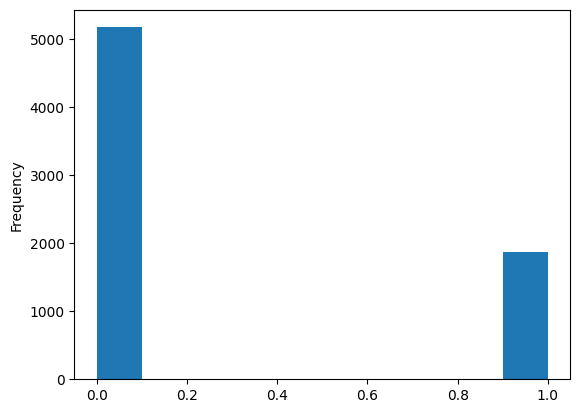

In [ ]:
df['Churn'].plot(kind = 'hist')

**Model Building (Using XgBoost & Logistic Regression)**

In [ ]:
# Data Splitting
from sklearn.model_selection import train_test_split
target = 'Churn'
X = df.drop(target, axis = 1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print (f'X_train shape: {X_train.shape}')
print (f'y_train shape: {y_train.shape}')
print (f'X_test shape: {X_test.shape}')
print (f'y_test shape: {y_test.shape}')

X_train shape: (5634, 17)
y_train shape: (5634,)
X_test shape: (1409, 17)
y_test shape: (1409,)


In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

In [ ]:
cat_cols = X_train.select_dtypes('object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers = [
     ('ordinal', OrdinalEncoder(), cat_cols)
    ],
    remainder = 'passthrough'
)

In [ ]:
clf = Pipeline(
    [
    ('preprocessor', preprocessor),
    ('Scaling', StandardScaler()),
    ('Smote', SMOTE(random_state = 42)),
    ('Xgb Boost', XGBClassifier())
]
)

In [ ]:
clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal', OrdinalEncoder(),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport',
                                                   'StreamingMovies',
                                                   'Contract', 'PaymentMethod',
                                                   'Customer Type'])])),
                ('Scaling', StandardScaler()),
                ('Smote', SMOTE(random_state=42)...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print (classification_report(y_test, y_pred))
print (confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1036
           1       0.59      0.63      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.79      1409

[[871 165]
 [139 234]]


In [ ]:
# If you have 900 'No' and 100 'Yes', scale_pos_weight = 9
#ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

#pipeline = Pipeline(steps=[
 #   ('preprocessor', preprocessor),
  #  ('classifier', XGBClassifier(scale_pos_weight=ratio))
#])

In [ ]:
# Hyper Parameter Tuning
params = {
    # Smote Tuning
    'Smote__k_neighbors': [3, 5],
    'Smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0],

    # XGBoost Tuning
    'Xgb Boost__n_estimators': [100, 200, 300],
    'Xgb Boost__max_depth': [3, 4, 5],
    'Xgb Boost__learning_rate': [0.01, 0.1, 0.2],
    'Xgb Boost__min_child_weight' : [3, 5, 7],
    'Xgb Boost__colsample_bytree' : [0.4, 0.6, 0.8, 1],
    'Xgb Boost__scale_pos_weight': [1, 3, 5, 10]
}

In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning
model = GridSearchCV(
    estimator = clf,
    param_grid = params,
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

model.fit(X_train, y_train)

Fitting 5 folds for each of 10368 candidates, totalling 51840 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinal',
                                                                         OrdinalEncoder(),
                                                                         ['gender',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaymentMethod',
                                                                          'Customer '
                                                                          'Type'])])),
                                       ('Scaling', StandardScaler()),
                                       (...
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'Smote__k_neighbors': [3, 5],
                         'Smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0],
                         'Xgb Boost__colsample_bytree': [0.4, 0.6, 0.8, 1],
                         'Xgb Boost__learning_rate': [0.01, 0.1, 0.2],
                         'Xgb Boost__max_depth': [3, 4, 5],
                         'Xgb Boost__min_child_weight': [3, 5, 7],
                         'Xgb Boost__n_estimators': [100, 200, 300],
                         'Xgb Boost__scale_pos_weight': [1, 3, 5, 10]},
             verbose=1)

In [ ]:
model.best_params_

{'Smote__k_neighbors': 3,
 'Smote__sampling_strategy': 0.5,
 'Xgb Boost__colsample_bytree': 0.4,
 'Xgb Boost__learning_rate': 0.01,
 'Xgb Boost__max_depth': 4,
 'Xgb Boost__min_child_weight': 3,
 'Xgb Boost__n_estimators': 200,
 'Xgb Boost__scale_pos_weight': 1}

In [ ]:
# Classification report of classifier on Actual Test_set
clf_y_pred = clf.predict(X_test)
print (classification_report(y_test, clf_y_pred))
print ('\n')
print (confusion_matrix(y_test, clf_y_pred))

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1036
           1       0.59      0.63      0.61       373

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.79      1409



[[871 165]
 [139 234]]


In [ ]:
# Classification report of hyper tuned Parameters on Actual Test_set
y_hyper_pred = model.predict(X_test)

print (classification_report(y_test, y_hyper_pred))
print ('\n')
print (confusion_matrix(y_test, y_hyper_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.67      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



[[930 106]
 [158 215]]


In [ ]:
# Saving Model
import pickle
with open ('XGB_model.pkl', 'wb') as f:
  pickle.dump(model, f)
print ('Model Saved Successfully')

Model Saved Successfully


In [ ]:
# If you have 900 'No' and 100 'Yes', scale_pos_weight = 9
# SEcond Classifier
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

clf_2 = Pipeline([
    ('preprocessor', preprocessor),
    ('Scaling', StandardScaler()),
    ('Xg Boost', XGBClassifier(scale_pos_weight=ratio))
])

clf_2.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal', OrdinalEncoder(),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport',
                                                   'StreamingMovies',
                                                   'Contract', 'PaymentMethod',
                                                   'Customer Type'])])),
                ('Scaling', StandardScaler()),
                ('Xg Boost',
                 XGBClassifier(base_s...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred_2 = clf_2.predict(X_test)

In [ ]:
# CLassification for The Second Method for Class Imbalance
print (classification_report(y_test, y_pred_2))
print ('/n')
print (confusion_matrix(y_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1036
           1       0.53      0.68      0.60       373

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

/n
[[814 222]
 [120 253]]


In [ ]:
# Hyper Parameter Tuning for second method
params = {
     # XGBoost Tuning
    'Xg Boost__n_estimators': [100, 200, 300],
    'Xg Boost__max_depth': [3, 4, 5],
    'Xg Boost__learning_rate': [0.01, 0.1, 0.2],
    'Xg Boost__colsample_bytree' : [0.4, 0.6, 0.8, 1],
      }

In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter Tuning
model_2 = GridSearchCV(
    estimator = clf_2,
    param_grid = params,
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

model_2.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinal',
                                                                         OrdinalEncoder(),
                                                                         ['gender',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaymentMethod',
                                                                          'Customer '
                                                                          'Type'])])),
                                       ('Scaling', StandardScaler()),
                                       (...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'Xg Boost__colsample_bytree': [0.4, 0.6, 0.8, 1],
                         'Xg Boost__learning_rate': [0.01, 0.1, 0.2],
                         'Xg Boost__max_depth': [3, 4, 5],
                         'Xg Boost__n_estimators': [100, 200, 300]},
             verbose=1)

In [ ]:
# CLassification for The Second Method for Class Imbalance
print (classification_report(y_test, y_pred_2))
print ('/n')
print (confusion_matrix(y_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1036
           1       0.53      0.68      0.60       373

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

/n
[[814 222]
 [120 253]]


In [ ]:
# Classification of the Hyper tuned Second Method for the Actual Set
y_hyper_pred_2 = model_2.predict(X_test)
print (classification_report(y_test, y_hyper_pred_2))
print ('/n')
print (confusion_matrix(y_test, y_hyper_pred_2))

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1036
           1       0.55      0.76      0.64       373

    accuracy                           0.77      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.77      0.78      1409

/n
[[807 229]
 [ 90 283]]


In [ ]:
# Saving Model
import pickle
with open ('XGB_model_2.pkl', 'wb') as f:
  pickle.dump(model_2, f)
print ('Model Saved Successfully')

Model Saved Successfully


In [ ]:
y_train.value_counts()

,count
Churn,
0,4138
1,1496


In [ ]:
# Building the Logistic Regression Model

cat_cols = X_train.select_dtypes('object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers = [
     ('OneHot Encoder', OneHotEncoder(drop = 'first'), cat_cols)
    ],
    remainder = 'passthrough'
)

In [ ]:
log_model = Pipeline(
    [
    ('preprocessor', preprocessor),
    ('Scaling', StandardScaler()),
    ('Logistic Regression', LogisticRegression())
]
)

log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHot Encoder',
                                                  OneHotEncoder(drop='first'),
                                                  ['gender', 'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport',
                                                   'StreamingMovies',
                                                   'Contract', 'PaymentMethod',
                                                   'Customer Type'])])),
                ('Scaling', StandardScaler()),
                ('Logistic Regression', LogisticRegression())])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# Classification Reports and Confusion Matrix for Logistic Regression
log_y_pred = log_model.predict(X_test)
print (classification_report(y_test, log_y_pred))
print ('\n')
print (confusion_matrix(y_test, log_y_pred))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.67      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



[[930 106]
 [157 216]]


In [ ]:
params = [
    {
      # Combo 1: L2 penalty with the default lbfgs solver
        'Logistic Regression__solver': ['lbfgs'],
        'Logistic Regression__penalty': ['l2'],
        'Logistic Regression__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'Logistic Regression__class_weight': ['balanced', None]
    },
    {
        # Combo 2: L1 penalty (requires liblinear solver)
        'Logistic Regression__solver': ['liblinear'],
        'Logistic Regression__penalty': ['l1'],
        'Logistic Regression__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'Logistic Regression__class_weight': ['balanced', None]
    }
]

In [ ]:
from sklearn.model_selection import GridSearchCV

hyper_log_model = GridSearchCV(
    estimator = log_model,
    param_grid = params,
    cv=5,
    n_jobs=-1,
    verbose=1
)

hyper_log_model.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('OneHot '
                                                                         'Encoder',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['gender',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaymentMethod',
                                                                          'Customer '
                                                                          'Type'])])),
                                       ('Scaling',...
             param_grid=[{'Logistic Regression__C': [0.001, 0.01, 0.1, 1, 10,
                                                     100],
                          'Logistic Regression__class_weight': ['balanced',
                                                                None],
                          'Logistic Regression__penalty': ['l2'],
                          'Logistic Regression__solver': ['lbfgs']},
                         {'Logistic Regression__C': [0.001, 0.01, 0.1, 1, 10,
                                                     100],
                          'Logistic Regression__class_weight': ['balanced',
                                                                None],
                          'Logistic Regression__penalty': ['l1'],
                          'Logistic Regression__solver': ['liblinear']}],
             verbose=1)

In [ ]:
hyper_log_model.best_params_

{'Logistic Regression__C': 0.1,
 'Logistic Regression__class_weight': None,
 'Logistic Regression__penalty': 'l1',
 'Logistic Regression__solver': 'liblinear'}

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
# Classification Reports and Confusion Matrix for Logistic Regression
log_y_pred = log_model.predict(X_test)
print (classification_report(y_test, log_y_pred))
print ('\n')
print (confusion_matrix(y_test, log_y_pred))


              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.67      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



[[930 106]
 [157 216]]


In [ ]:
# Classification Reports and Confusion Matrix for Tuned Logistic Regression
hyper_log_y_pred = hyper_log_model.predict(X_test)
print (classification_report(y_test, hyper_log_y_pred))
print ('\n')
print (confusion_matrix(y_test, hyper_log_y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409



[[938  98]
 [165 208]]


***The Best Model Here is Clearly the XG Boost with the scaled pos weight***

In [ ]:
def predict_function (df):
  """
  Returns predicted values for the given dataframe

  Parameters:
  df (pandas.DataFrame): The input dataframe

  Returns:
  pandas.Series: The predicted values
  """
  # load the saved model
  with open ('XGB_model_2.pkl', 'rb') as f:
    model = pickle.load(f)

  # predict the values
  predicted_values = model.predict(df)

  return predicted_values
